In [2]:
import sys
import os
sys.path.append(os.path.abspath('../'))

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import PharmacokineticUDE
from src.data_gen import generate_dataset

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({"font.size": 12, "figure.dpi": 120})

In [3]:
print("[*] Levantando el modelo entrenado...")

#Se instancia la arquitectura vacía
model = PharmacokineticUDE(hidden_dim=16)

#Se cargan los pesos descubiertos por train.py
model_path = '../checkpoints/ude_model_final.pth'
model.load_state_dict(torch.load(model_path))

#Se evalúa el modelo
model.eval()

#Se carga el ruido que el modelo descubrió
noise_path = '../checkpoints/noise_params_final.pth'
noise_params = torch.load(noise_path)

#Se imprimen los parámetros de la física que descubrió
kB_descubierto = model.ude_field.k_B.item()
print(f"-> Tasa de eliminación (k_B) aprendida: {kB_descubierto:.4f} (Real aprox: 0.2000)")

s_add_A = F.softplus(noise_params['add_A']).item()
s_prop_A = F.softplus(noise_params['prop_A']).item()
print(f"-> Ruido Droga A estimado | Aditivo: {s_add_A:.3f}, Proporcional: {s_prop_A:.3f}")

[*] Levantando el modelo entrenado...
-> Tasa de eliminación (k_B) aprendida: 0.1956 (Real aprox: 0.2000)
-> Ruido Droga A estimado | Aditivo: 0.527, Proporcional: 0.191


C:\Users\lucap\AppData\Local\Temp\ipykernel_3208\3459587630.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
C:\Users\lucap\

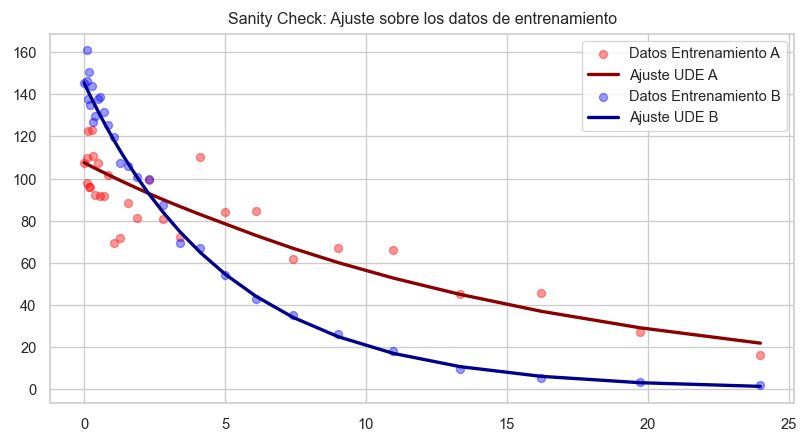

In [4]:
#Se cargan los datos de entrenamiento
df_train = pd.read_csv('../data/synthetic/ddi_synthetic_data.csv')
t_train = torch.tensor(df_train['time'].values, dtype=torch.float32)
u0_train = torch.tensor([df_train['obs_A'].iloc[0], df_train['obs_B'].iloc[0]], dtype=torch.float32)

#Se realizan las predicciones
with torch.no_grad():
    pred_train = model(u0_train, t_train).numpy()

#Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
t_np = t_train.numpy()

ax.scatter(t_np, df_train['obs_A'], color='red', alpha=0.4, label='Datos Entrenamiento A')
ax.plot(t_np, pred_train[:, 0], color='darkred', linewidth=2, label='Ajuste UDE A')

ax.scatter(t_np, df_train['obs_B'], color='blue', alpha=0.4, label='Datos Entrenamiento B')
ax.plot(t_np, pred_train[:, 1], color='darkblue', linewidth=2, label='Ajuste UDE B')

ax.set_title("Sanity Check: Ajuste sobre los datos de entrenamiento")
ax.legend()
plt.show()

[*] Generando paciente de prueba con sobredosis de A (A=250) y poco inhibidor (B=50)


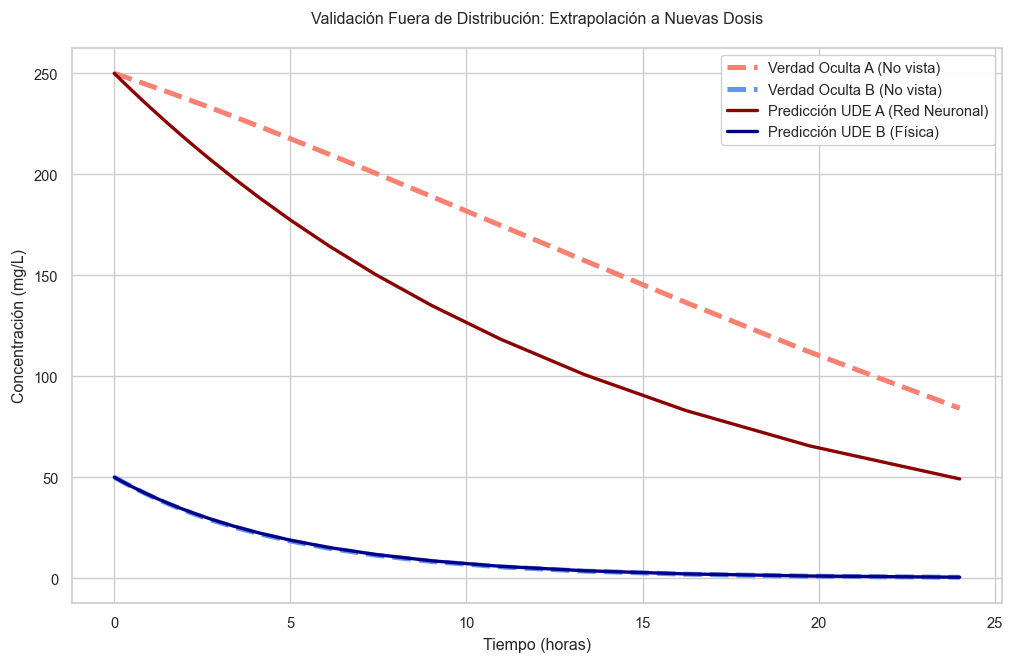

In [5]:
print("[*] Generando paciente de prueba con sobredosis de A (A=250) y poco inhibidor (B=50)")
#Se utiliza data_gen para generar la verdad de este nuevo paciente
df_test = generate_dataset(A0=250.0, B0=50.0, save_to_csv=False)

#Se extrae el tiempo y la nueva condición inicial
t_test = torch.tensor(df_test['time'].values, dtype=torch.float32)
u0_test = torch.tensor([250.0, 50.0], dtype=torch.float32)

#Se realiza la predicción
with torch.no_grad():
    pred_test = model(u0_test, t_test).numpy()

#Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
t_np = t_test.numpy()

#Verdad del paciente
ax.plot(t_np, df_test['true_A'], '--', color='salmon', linewidth=3, label='Verdad Oculta A (No vista)')
ax.plot(t_np, df_test['true_B'], '--', color='cornflowerblue', linewidth=3, label='Verdad Oculta B (No vista)')

#Predicción de la UDE para el paciente
ax.plot(t_np, pred_test[:, 0], color='darkred', linewidth=2, label='Predicción UDE A (Red Neuronal)')
ax.plot(t_np, pred_test[:, 1], color='darkblue', linewidth=2, label='Predicción UDE B (Física)')

ax.set_title("Validación Fuera de Distribución: Extrapolación a Nuevas Dosis", pad=15)
ax.set_xlabel("Tiempo (horas)")
ax.set_ylabel("Concentración (mg/L)")
ax.legend(loc='upper right', framealpha=0.9)
plt.show()

In [ ]:
import torch
import numpy as np
import pandas as pd
from src.optim import heteroscedastic_nll_loss

# 1. Cargamos el dataset completo
df = pd.read_csv('../data/synthetic/ddi_synthetic_data.csv')

# 2. Extraemos las observaciones (Y) y la VERDAD continua (X) que usamos para simular
target_data = torch.tensor(np.stack([df['obs_A'].values, df['obs_B'].values], axis=-1), dtype=torch.float32)
true_data = torch.tensor(np.stack([df['true_A'].values, df['true_B'].values], axis=-1), dtype=torch.float32)

# 3. Ponemos los parámetros de ruido REALES con los que creamos el dataset en data_gen.py
# Recordá pasarlos por el inverso de Softplus si la función los des-transforma,
# o simplemente podés mockear la función de pérdida para pasarle los sigmas directos.
# Supongamos que hardcodeamos los sigmas reales (add_A=2.0, prop_A=0.15, add_B=1.0, prop_B=0.05)
# Calculamos la Loss usando 'true_data' como la predicción perfecta:

def loss_teorica_perfecta():
    pred_A, pred_B = true_data[..., 0], true_data[..., 1]
    targ_A, targ_B = target_data[..., 0], target_data[..., 1]
    
    # Sigmas reales del biosensor con los que creamos el universo sintético
    s_add_A, s_prop_A = 2.0, 0.15
    s_add_B, s_prop_B = 1.0, 0.05
    
    # Varianzas teóricas perfectas
    var_A = s_add_A**2 + (s_prop_A * pred_A)**2
    var_B = s_add_B**2 + (s_prop_B * pred_B)**2
    
    # Negative Log-Likelihood pura, limpia y completamente vectorial
    loss_A = 0.5 * (((targ_A - pred_A)**2 / var_A) + torch.log(var_A))
    loss_B = 0.5 * (((targ_B - pred_B)**2 / var_B) + torch.log(var_B))
    
    return torch.mean(loss_A + loss_B).item()

print("Loss teórica perfecta:", loss_teorica_perfecta())
print("Loss que obtuvo tu UDE entrenada:", 4.97)

Loss teórica perfecta (si el modelo fuera Dios): 4.747220039367676
Loss que obtuvo tu UDE entrenada: 4.97
